# Controllable STFT demo

Same workflow as `demo.ipynb`, but the frontend is `ControllableSTFT` instead of `SincNet`.
Pick the two axes you control directly — `fps` and `n_bins` (ideally powers of two) — and the
overlap. The STFT overlap-adds with exact COLA normalisation, so `decode(encode(x))` is exactly
invertible with **no aliasing and no horizontal stripes**.

In [1]:
import torch

import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from IPython.display import HTML, display

from sincnet import STFT, stft_params
from sincnet.mulaw import MuLawQuant, mu_law_compand, mu_law_expand
from datasets.utils.waveform import WaveformLoader
from training.utils.stft import TorchSTFT

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
#SAMPLE_RATE = 44100
SAMPLE_RATE = 16000
audio_loader = WaveformLoader(sample_rate=SAMPLE_RATE)

Initializing PreprocessingWaveformLoader with sample rate sr:16000...


In [4]:
params = {
    "fs": SAMPLE_RATE,
    "fps": 128,        # frames per second  (fps = fs / hop);  power of two <= 128 for fs=16000
    "n_bins": 128,     # frequency bins      (power of two; highest/Nyquist bin is dropped)
    "overlap": 2,      # window overlap      (2 -> 50%, 4 -> 75%);  needs n_bins >= overlap*fs/(2*fps)
    "q_bits": 8,
    "layout": "channel",  # (B, 2, F, T) real, like SincNet's complex component
}

# resolved STFT knobs (hop / n_fft / win) for the chosen axes
print(stft_params(params["fs"], params["fps"], params["n_bins"], params["overlap"]))

cstft : STFT = (
    STFT(**params)
    .eval()
    .to(device)
)
cstft

{'n_fft': 256, 'win_length': 250, 'hop_length': 125}


STFT(
  (mulaw): MuLawQuant()
)

In [5]:
n_fft = 1024
win_length = 1024
hop_length = win_length // 4
stft = TorchSTFT(sample_rate=params["fs"], n_fft=n_fft, hop_length=hop_length, win_length=win_length).to(device)

## 1 - Invertibility Test

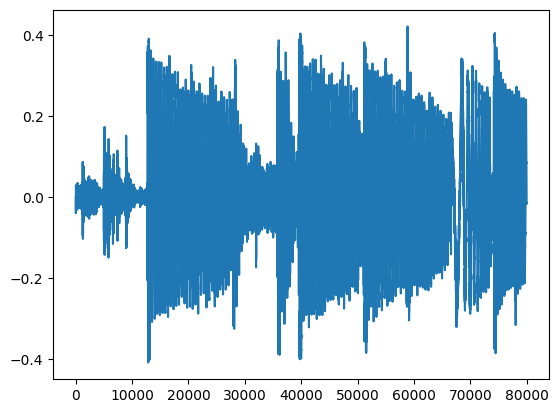

In [6]:
audio_pathes = {
    1:"audio/invertibility/p232_001.wav",
    2:"audio/invertibility/p232_002.wav",
    3:"audio/invertibility/15033000.mp3",
    4:"audio/invertibility/16366200.mp3",
    5:"audio/invertibility/16129994.mp3",
    6:"audio/invertibility/16176213.mp3",
}

audio_path = audio_pathes[3]
#audio_path = "audio/space-of-soul.mp3"
audio_path = "audio/backwhen-watermane-deep-water.mp3"
#audio_path = "audio/stellardrone-billions-and-billions-spaceambient.mp3"

waveform = audio_loader.load_segment(audio_path, offset=15, duration=5, nchannels=1)
loudness = audio_loader.measure_loudness(waveform)
waveform = audio_loader.normalise_loudness(waveform, loudness, target_lufs=-23)

plt.plot(waveform[0])
ipd.Audio(waveform, rate=SAMPLE_RATE, autoplay=False)

wav_in tensor(-0.4093) tensor(0.4220) torch.Size([1, 80000])
wav_ou tensor(-0.4095) tensor(0.4195) torch.Size([1, 80000])
pr-spec: tensor(-34.5088) tensor(40.0929)
cq-spec: tensor(3) tensor(255)
dq-spec: tensor(-35.1707) tensor(40.0943)


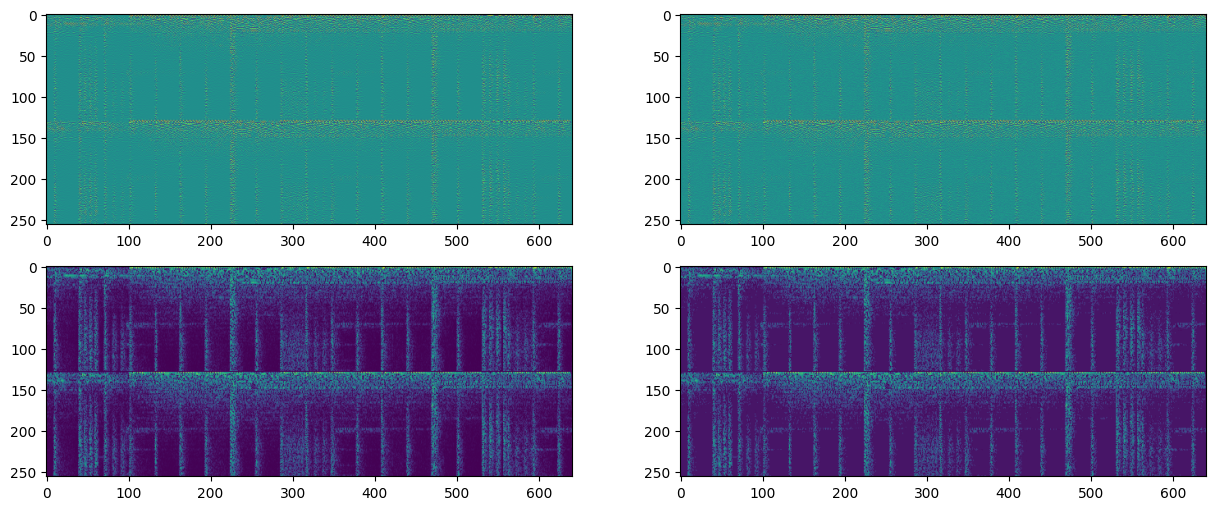

In [7]:
q_bits = params["q_bits"]
quantizer = cstft.mulaw   # the built-in MuLawQuant, like sinc.mulaw


with torch.no_grad():
    # transform the waveform into a tensor
    wav = torch.from_numpy(waveform).to(device).float()
    length = wav.shape[-1]
    print("wav_in", wav.min(), wav.max(), wav.shape)

    # encode and decode waveform (pass length for exact output sizing)
    spec = s = cstft.encode(wav)
    reconstructed_wav = cstft.decode(s, length=length)

    print("wav_ou", reconstructed_wav.min(), reconstructed_wav.max(), reconstructed_wav.shape)
    print("pr-spec:", s.min(), s.max())

    # apply quantization
    sq, scale = quantizer.quantize(s)
    print("cq-spec:", sq.min(), sq.max())
    sr = quantizer.dequantize(sq, scale)
    print("dq-spec:", sr.min(), sr.max())
    detokenized_wav = cstft.decode(sr, length=length)

    # apply mu-law-companding for visualization
    s = mu_law_compand(s, q_bits=q_bits)
    sr = mu_law_compand(sr, q_bits=q_bits)

    m = torch.sqrt(s[:,0]**2 + s[:,1]**2) if s.shape[1] > 1 else s[:,0].abs()
    mr = torch.sqrt(sr[:,0]**2 + sr[:,1]**2) if sr.shape[1] > 1 else sr[:,0].abs()

    # reduce to 2D for visualization (average over channels mono/stereo and frequencies)
    s = s.flatten(1,2).mean(dim=0)
    sr = sr.flatten(1,2).mean(dim=0)


f, axes = plt.subplots(2, 2, figsize=(15, 6))

y = s.detach().cpu().numpy()
yr = sr.detach().cpu().numpy()

axes[0,0].imshow(y)
axes[1,0].imshow(np.abs(y))

axes[0,1].imshow(yr)
axes[1,1].imshow(np.abs(yr))

# Create your Audio objects
audio1 = ipd.Audio(reconstructed_wav.cpu(), rate=SAMPLE_RATE, autoplay=False)
audio2 = ipd.Audio(detokenized_wav.cpu(), rate=SAMPLE_RATE, autoplay=False)
# Embed them in HTML with flexbox for horizontal layout
html_content = f"""
<div style="display:flex; justify-content:space-around;">
    <div>
        <h3>Reconstructed waveform</h3>
        {audio1._repr_html_()}
    </div>
    <div>
        <h3>Dequantized waveform</h3>
        {audio2._repr_html_()}
    </div>
</div>
"""
# Display the HTML
display(HTML(html_content))

Text(0.5, 1.0, 'STFT(decode(encode(x)))')

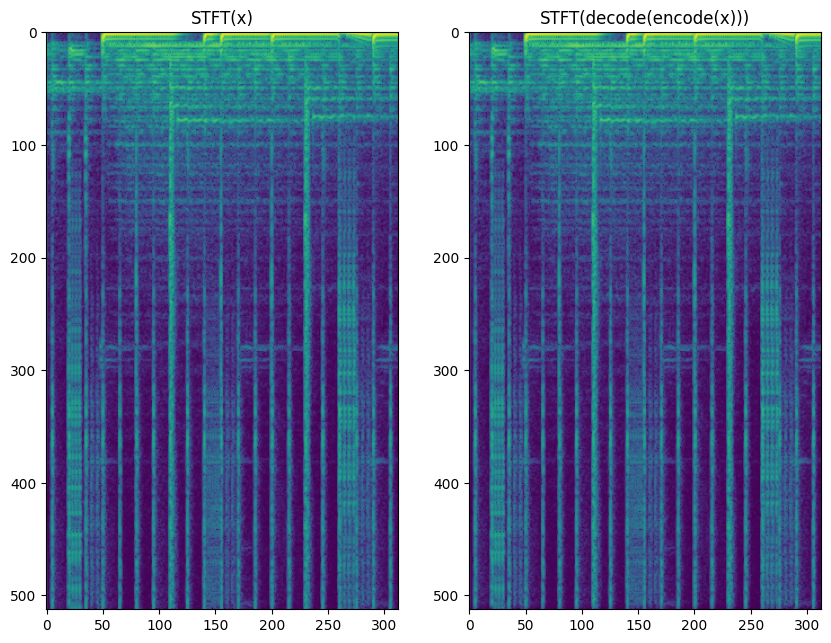

In [8]:
def compute_log1p_stft(waveform:torch.Tensor, n_bits:int=8) -> torch.Tensor:
    """compute log1p stft and return spectrogram"""
    spectrograms = stft.compute_log1p_magnitude(waveform, n_bits=n_bits).unsqueeze(0)
    return spectrograms

stft_wav = compute_log1p_stft(wav)
sfft_rec = compute_log1p_stft(reconstructed_wav)

f, axes = plt.subplots(1, 2, figsize=(10, 20))
axes[0].imshow(stft_wav[0,0,0].cpu())
axes[0].set_title("STFT(x)")
axes[1].imshow(sfft_rec[0,0,0].cpu())
axes[1].set_title("STFT(decode(encode(x)))")

In [9]:
# reconstruction SNR (the STFT is exactly invertible up to the dropped Nyquist bin)
x = wav
noise = wav - reconstructed_wav[..., :length]
snr = 10 * torch.log10(x.pow(2).mean() / noise.pow(2).mean())
print("reconstruction SNR (dB):", snr.item())

reconstruction SNR (dB): 48.6236572265625


### Griffin-Lim (phase from magnitude only)

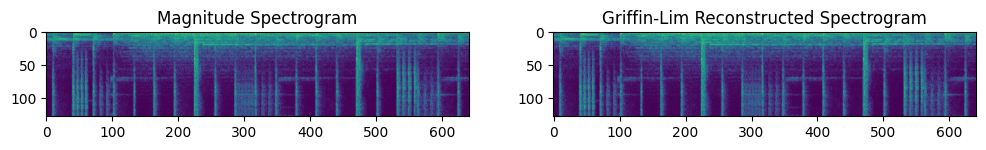

In [10]:
n_iters = 50
mag = cstft.magnitude(spec)
mag_mulaw = mu_law_compand(mag, q_bits=q_bits)
rspec = cstft.griffin_lim(mag, n_iters=n_iters)
rwav = cstft.decode(rspec, length=length)

rmag = cstft.magnitude(rspec)
rmag_mulaw = mu_law_compand(rmag, q_bits=q_bits)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(mag_mulaw[0,0].cpu().numpy())
axes[0].set_title("Magnitude Spectrogram")
axes[1].imshow(rmag_mulaw[0,0].cpu().numpy())
axes[1].set_title("Griffin-Lim Reconstructed Spectrogram")

ipd.Audio(rwav.cpu().numpy(), rate=SAMPLE_RATE, autoplay=False)

## 2 - Linearity Test

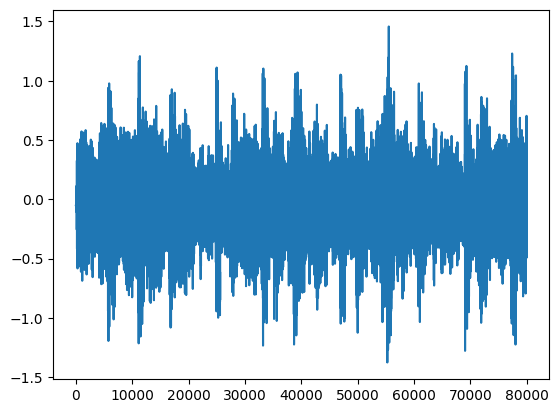

In [11]:
audio_pathes = {
    0:"audio/stems/stem_pad.wav",
    1:"audio/stems/stem_drum1.wav",
    2:"audio/stems/stem_drum2.wav",

}

selection = [0,2]

wavs = []
for choice in selection:
    audio_path = audio_pathes[choice]
    waveform = audio_loader.load_segment(audio_path, offset=0, duration=5, nchannels=1)
    wavs.append(waveform)

mix = sum(wavs)
wavs.insert(0, mix)

plt.plot(mix[0])
ipd.Audio(mix, rate=SAMPLE_RATE, autoplay=False)

In [12]:
spectrograms = []
reconstructed = []

with torch.no_grad():
    for i, waveform in enumerate(wavs):
        x = torch.from_numpy(waveform).to(device).float()
        s = cstft.encode(x)
        spectrograms.append(s)
        wav = cstft.decode(s, length=x.shape[-1])
        reconstructed.append(wav)

        display(ipd.Audio(waveform, rate=SAMPLE_RATE, autoplay=False))

In [13]:
# the STFT is linear: encode(mix) == sum of encode(stems)
s_mix_true = spectrograms[0]
s_mix_linear = torch.cat(spectrograms[1:], dim=0).sum(dim=0)
rel_err = (s_mix_true - s_mix_linear).norm() / s_mix_true.norm()
print("linearity relative error:", rel_err.item())
assert rel_err < 1e-4
print("linearity OK")

linearity relative error: 1.3812780252919765e-07
linearity OK
